#  Malicious URL Classification - Full Dataset
##  Train RandomForest on 140K URLs


In [44]:
import pandas as pd
import numpy as np
!pip install xgboost
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack, csr_matrix


### 1. Load Full Dataset


In [45]:
import gdown
import pandas as pd

# Google Drive file ID
file_id = "1tJGGAqPQfIYA1xcGFzu2NTOXmCasyAKk"

# Direct download URL
download_url = f"https://drive.google.com/uc?id={file_id}"
output = "Malicious_URLs.csv"

# Download the file
gdown.download(download_url, output, quiet=False)

# Read CSV into DataFrame
df = pd.read_csv(output)
df.columns = ["url", "label"]  # rename columns
df = df.sample(n=20000, random_state=42)  # ✅ Reduce to 20k URLs for faster training
print("✅ Total samples:", len(df))
print(df.head())


Downloading...
From: https://drive.google.com/uc?id=1tJGGAqPQfIYA1xcGFzu2NTOXmCasyAKk
To: /content/Malicious_URLs.csv
100%|██████████| 22.8M/22.8M [00:00<00:00, 41.8MB/s]


✅ Total samples: 20000
                                                      url label
153858  en.wikipedia.org/wiki/Uptown_Theater_(Kansas_C...  good
268846  kktv.com/sports/headlines/Mountain_West_Confer...  good
119204                             flashionista.org/?p=49  good
225271  3designcenter.com/blog/wp-admin/network/other/...   bad
147290  obits.dignitymemorial.com/dignity-memorial/obi...  good


### 2. Clean & Preprocess


In [46]:
df.dropna(inplace=True)
df.drop_duplicates(subset="url", inplace=True)
df["label"] = df["label"].apply(lambda x: 0 if str(x).lower() == "good" else 1)


### 3. Feature Engineering


In [47]:
def has_ip(url): return int(bool(re.search(r"\d+\.\d+\.\d+\.\d+", url)))
def has_https(url): return int("https" in url.lower())
def count_char(url, char): return url.count(char)
def contains_suspicious_words(url):
    words = ["login", "account", "secure", "bank", "verify", "update"]
    return int(any(word in url.lower() for word in words))
def extract_tld(url):
    try: return url.split('.')[-1].split('/')[0]
    except: return 'unknown'

df["url_length"] = df["url"].apply(len)
df["dot_count"] = df["url"].apply(lambda x: count_char(x, '.'))
df["dash_count"] = df["url"].apply(lambda x: count_char(x, '-'))
df["slash_count"] = df["url"].apply(lambda x: count_char(x, '/'))
df["has_ip"] = df["url"].apply(has_ip)
df["has_https"] = df["url"].apply(has_https)
df["has_suspicious_words"] = df["url"].apply(contains_suspicious_words)
df["tld"] = df["url"].apply(extract_tld)

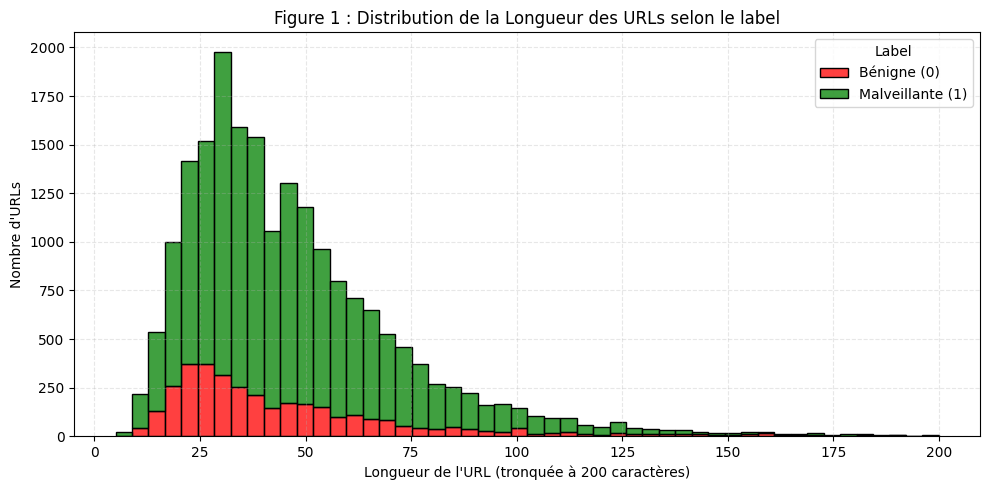

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

#  cap URL lengths to a reasonable max (e.g. 200 chars) for better visualization
df_plot = df.copy()
df_plot = df_plot[df_plot["url_length"] <= 200]  # Most URLs fall below 200 chars

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_plot,
    x="url_length",
    hue="label",
    bins=50,
    kde=False,
    palette={0: "green", 1: "red"},
    multiple="stack"
)

plt.title("Figure 1 : Distribution de la Longueur des URLs selon le label")
plt.xlabel("Longueur de l'URL (tronquée à 200 caractères)")
plt.ylabel("Nombre d'URLs")
plt.legend(title="Label", labels=["Bénigne (0)", "Malveillante (1)"])
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


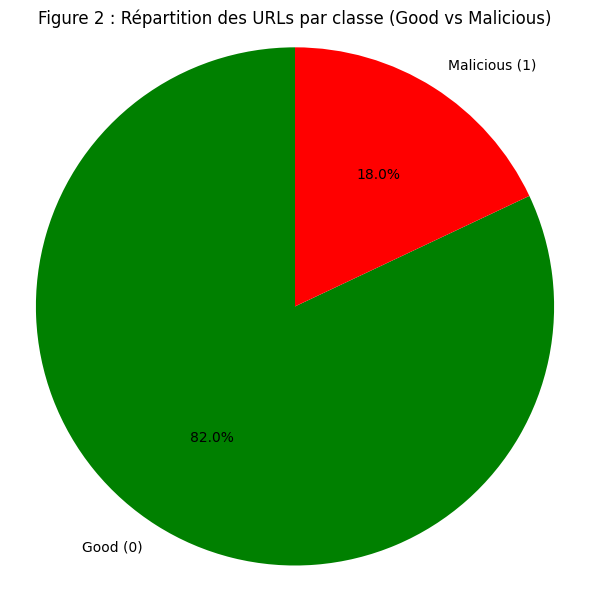

In [49]:
# Pie chart of label distribution
label_counts = df["label"].value_counts()
labels = ["Good (0)", "Malicious (1)"]
colors = ["green", "red"]

plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Figure 2 : Répartition des URLs par classe (Good vs Malicious)")
plt.axis('equal')
plt.tight_layout()
plt.show()


##### Group rare TLDs

In [50]:
tld_counts = df['tld'].value_counts()
tld_to_keep = tld_counts[tld_counts > 20].index
df['tld'] = df['tld'].apply(lambda x: x if x in tld_to_keep else 'other')
df = pd.get_dummies(df, columns=["tld"])

### 4. TF-IDF on URLs (Optimized)


In [51]:
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=3000)
X_text = vectorizer.fit_transform(df["url"])


### 5. Combine Features + TF-IDF


In [52]:
X_features = df.drop(columns=["url", "label"])
X_sparse = csr_matrix(X_features.astype(np.float32).values)
X = hstack([X_sparse, X_text])
y = df["label"]

Min : 0
1er quartile : 28.0
Médiane : 44.0
3e quartile : 60.0
Max : 255


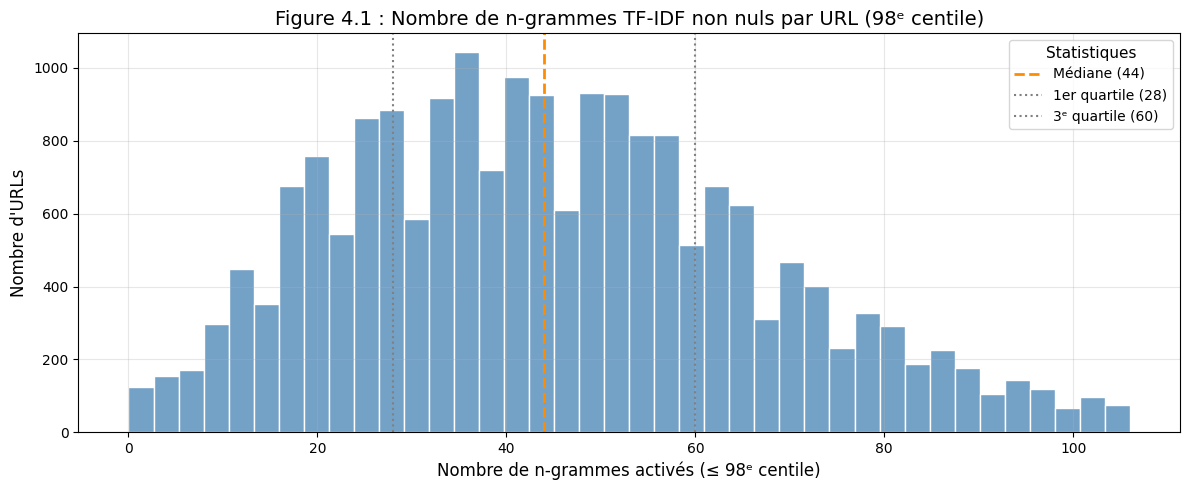

In [53]:
nnz_per_url = X_text.getnnz(axis=1)  # tableau de longueur n_urls
import numpy as np
print("Min :",             nnz_per_url.min())
print("1er quartile :",    np.percentile(nnz_per_url, 25))
print("Médiane :",         np.median(nnz_per_url))
print("3e quartile :",     np.percentile(nnz_per_url, 75))
print("Max :",             nnz_per_url.max())
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Supposons que nnz_per_url est déjà défini
# Exclure les valeurs extrêmes au-delà du 98e centile pour mieux visualiser la majeure partie des URLs
p98 = np.percentile(nnz_per_url, 98)
filtered = nnz_per_url[nnz_per_url <= p98]

# Calculer quelques statistiques
median = np.median(nnz_per_url)
q1, q3 = np.percentile(nnz_per_url, [25, 75])

plt.figure(figsize=(12, 5))
sns.histplot(filtered, bins=40, color="steelblue", edgecolor="white")
plt.title("Figure 4.1 : Nombre de n-grammes TF-IDF non nuls par URL (98ᵉ centile)", fontsize=14)
plt.xlabel("Nombre de n-grammes activés (≤ 98ᵉ centile)", fontsize=12)
plt.ylabel("Nombre d'URLs", fontsize=12)

# Ajouter des lignes de quartiles et de médiane
plt.axvline(median, color="darkorange", linestyle="--", linewidth=2, label=f"Médiane ({median:.0f})")
plt.axvline(q1, color="gray", linestyle=":", linewidth=1.5, label=f"1er quartile ({q1:.0f})")
plt.axvline(q3, color="gray", linestyle=":", linewidth=1.5, label=f"3ᵉ quartile ({q3:.0f})")

plt.legend(title="Statistiques", fontsize=10, title_fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




/tmp/ipython-input-551002334.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values_before, palette=["lightgreen","tomato"])


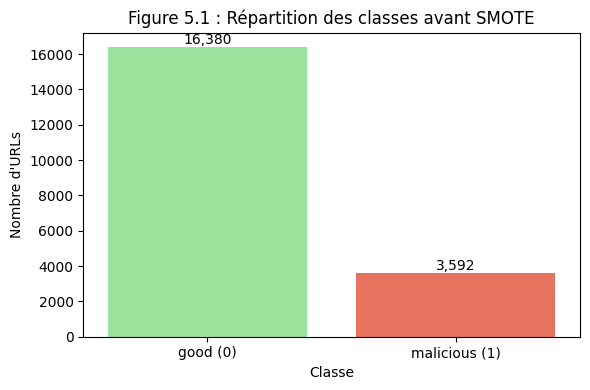

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- Figure 5.1 : Répartition des classes AVANT SMOTE ---
# Supposons que 'df' est votre DataFrame nettoyé (après NaN/doublons), avec df["label"] binaire 0/1.

counts_before = df["label"].value_counts().sort_index()  # index 0 puis 1
labels = ['good (0)', 'malicious (1)']
values_before = [counts_before[0], counts_before[1]]

plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=values_before, palette=["lightgreen","tomato"])
plt.title("Figure 5.1 : Répartition des classes avant SMOTE")
plt.ylabel("Nombre d'URLs")
plt.xlabel("Classe")
for i, v in enumerate(values_before):
    plt.text(i, v + max(values_before)*0.01, f"{v:,}", ha='center')
plt.tight_layout()
plt.show()


### 6. SMOTE for Class Imbalance


In [55]:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

/tmp/ipython-input-4284595764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values_after, palette=["lightgreen","tomato"])


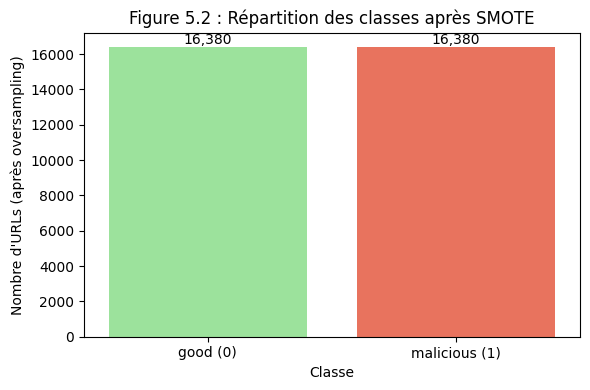

In [56]:
# --- Figure 5.2 : Répartition des classes APRÈS SMOTE ---
counts_after = Counter(y_res)  # ou y_res.value_counts()
values_after = [counts_after[0], counts_after[1]]

plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=values_after, palette=["lightgreen","tomato"])
plt.title("Figure 5.2 : Répartition des classes après SMOTE")
plt.ylabel("Nombre d'URLs (après oversampling)")
plt.xlabel("Classe")
for i, v in enumerate(values_after):
    plt.text(i, v + max(values_after)*0.01, f"{v:,}", ha='center')
plt.tight_layout()
plt.show()

### 7. Train/Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

Répartition dans l'ensemble d'entraînement :
       count  pct (%)
label                
0      13104     50.0
1      13104     50.0

Répartition dans l'ensemble de test :
       count  pct (%)
label                
0       3276     50.0
1       3276     50.0


/tmp/ipython-input-2082104090.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette=["lightgreen","tomato"])
/tmp/ipython-input-2082104090.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["good (0)", "malicious (1)"])
/tmp/ipython-input-2082104090.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette=["lightgreen","tomato"])
/tmp/ipython-input-2082104090.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_

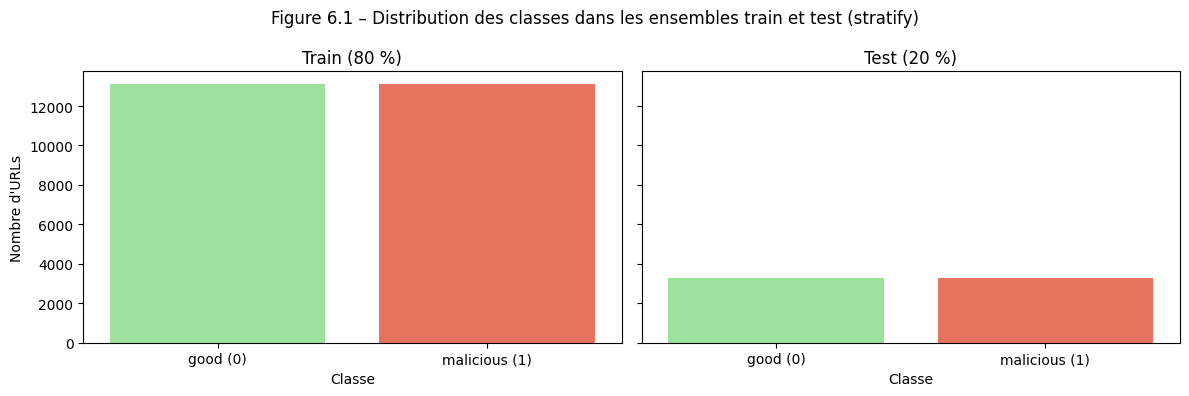

In [58]:
# 2. Comptage des labels dans chaque sous-ensemble
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

# 3. Pourcentages
train_pct = train_counts / train_counts.sum() * 100
test_pct  = test_counts  / test_counts.sum()  * 100

print("Répartition dans l'ensemble d'entraînement :")
print(pd.DataFrame({"count": train_counts, "pct (%)": train_pct.round(1)}))
print("\nRépartition dans l'ensemble de test :")
print(pd.DataFrame({"count": test_counts, "pct (%)": test_pct.round(1)}))

# 4. Visualisation côte-à-côte
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], palette=["lightgreen","tomato"])
axes[0].set_title("Train (80 %)"); axes[0].set_xlabel("Classe"); axes[0].set_ylabel("Nombre d'URLs")
axes[0].set_xticklabels(["good (0)", "malicious (1)"])

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], palette=["lightgreen","tomato"])
axes[1].set_title("Test (20 %)"); axes[1].set_xlabel("Classe")
axes[1].set_xticklabels(["good (0)", "malicious (1)"])

fig.suptitle("Figure 6.1 – Distribution des classes dans les ensembles train et test (stratify)")
plt.tight_layout()
plt.show()


### 8. Train Best Model (RandomForest)


In [59]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

### 9. Evaluation


In [ ]:
y_pred = rf.predict(X_test)
print("✅ Evaluation on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred))

# **SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1) Train the SVM on your current dataset
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

# 2) Predict on test set
y_pred_svm = svm.predict(X_test)

# 3) Evaluation
print("\n=== SVM Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))



# **XGBOOST**

In [62]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", xgb_acc)


XGBoost Accuracy: 0.9540598290598291
